In [2]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
df = pd.read_csv('Dataset - Dataset.csv.csv')

In [3]:
df

,CustomerID,Name,Age,Gender,Annual Income (k$),Spending Score (1-100)
0,1,Khaled,37.0,Male,27.483571,23.692333
1,2,Mostafa,20.0,Male,24.308678,20.856841
2,3,Sara,24.0,Female,28.238443,19.421759
3,4,Nada,48.0,Female,32.615149,18.494482
4,5,Hassan,20.0,Male,23.829233,12.607390
...,...,...,...,...,...,...
195,196,Mona,24.0,Female,84.987353,82.654122
196,197,Hassan,34.0,Male,89.907434,76.434327
197,198,Ali,21.0,Male,88.556707,91.769362
198,199,Omar,37.0,Male,91.613593,84.427301


In [4]:
#selecting numerical features and scaling them

features = df.select_dtypes(include=['int64', 'float64'])

imputer = SimpleImputer(strategy='mean')
features_imputed = imputer.fit_transform(features)

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_imputed)

features_scaled = pd.DataFrame(features_scaled, columns=features.columns)
features_scaled.dropna()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
0,-1.723412,0.650104,-0.828104,-1.090060
1,-1.706091,-1.430773,-0.929747,-1.183998
2,-1.688771,-0.941155,-0.803937,-1.231542
3,-1.671450,1.996554,-0.663817,-1.262262
4,-1.654129,-1.430773,-0.945096,-1.457297
...,...,...,...,...
195,1.654129,-0.941155,1.012868,0.863305
196,1.671450,0.282890,1.170383,0.657247
197,1.688771,-1.308368,1.127140,1.165287
198,1.706091,0.650104,1.225005,0.922049


In [5]:
#making k means using elbow method
wcss = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(features_scaled)
    wcss.append(model.inertia_)

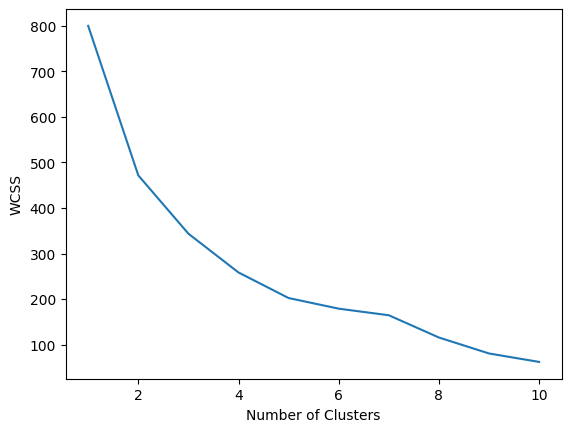

In [6]:
plt.plot(range(1, 11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [7]:
#insetring bes k means 
model = KMeans(n_clusters=4, random_state=42)
model.fit(features_scaled)

KMeans(n_clusters=4, random_state=42)

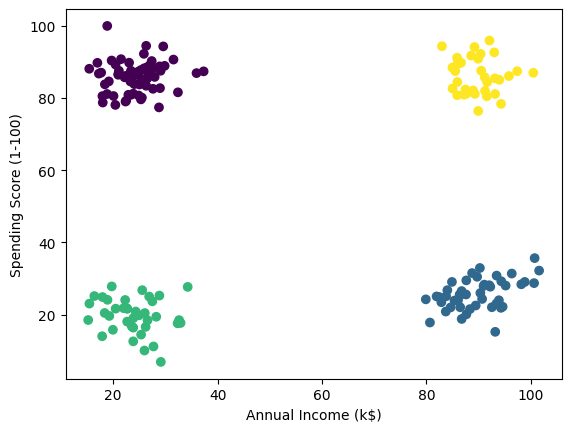

In [8]:
# plotting clusters
df['Kmeans Cluster'] = model.predict(features_scaled)

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Kmeans Cluster'])
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

In [11]:
#info about customers in four clusters needed for future decisions
summary = (df.groupby('Kmeans Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
             .mean()
             .round(1))
print("Cluster Profiles:\n", summary)
print("\nCluster Sizes:\n", df['Kmeans Cluster'].value_counts().sort_index())

Cluster Profiles:
                  Age  Annual Income (k$)  Spending Score (1-100)
Kmeans Cluster                                                  
0               30.9                24.3                    85.9
1               32.0                89.8                    25.7
2               32.3                24.0                    19.7
3               31.9                89.8                    86.2

Cluster Sizes:
 Kmeans Cluster
0    72
1    46
2    39
3    43
Name: count, dtype: int64
